<a href="https://colab.research.google.com/github/Lmarra1/drone_dynamics/blob/main/crazyflie_drone_dynamics_sympy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Crazyflie 2.1 dynamics with SymPy

Drone model from with **Crazyflie 2.1** parameters.

$$
\dot{\mathbf p} = \mathbf v,\qquad
\dot{\mathbf q} = \tfrac12\,\mathbf q \odot \begin{bmatrix}0\\ \boldsymbol\omega\end{bmatrix},\qquad
\dot{\mathbf v} = \mathbf g + \tfrac1m R(\mathbf q)\,\mathbf f_T - R(\mathbf q)\,D\,R(\mathbf q)^\top(\mathbf v-\mathbf v_w),\qquad
\dot{\boldsymbol\omega} = J^{-1}\big(\boldsymbol\tau - \boldsymbol\omega\times J\boldsymbol\omega\big)
$$

State $\mathbf x = [\mathbf p,\ \mathbf q,\ \mathbf v,\ \boldsymbol\omega]\in\mathbb R^{13}$, input $\mathbf u=[f_1,f_2,f_3,f_4]$ (rotor thrusts, N), disturbance $\mathbf v_w$ = wind velocity in the world frame.

**Conventions**
- World frame $I$: $z$ axis pointing up, $\mathbf g = [0,0,-9.81]$
- Body frame $B$: $x$ forward, $y$ left, $z$ up (Crazyflie convention)
- Hamilton quaternion $\mathbf q=[q_w,q_x,q_y,q_z]$, $R(\mathbf q)$ rotates vectors from $B$ to $I$
- Motors as in the firmware: M1 front-right, M2 back-right, M3 back-left, M4 front-left

**Contents:** 0. Imports · 1. Parameters · 2. Symbols · 3. Quaternions · 4. Mixer · 5. Dynamics · 6. Linearization · 7. Export for MPC · 7b. Linearization check · 8. Joystick simulation · 9. Plots

## 0. Imports

In [ ]:
import os
import importlib.util
import numpy as np
import sympy as sp
from scipy.linalg import expm
import matplotlib.pyplot as plt
from IPython.display import display, Math

sp.init_printing()               # render SymPy output as LaTeX

np.set_printoptions(precision=4, suppress=True, linewidth=140)
OUT_DIR = os.getcwd()           # files are saved next to the notebook

## 1. Crazyflie 2.1 numerical parameters

Every number has its source in the comments. Set `VARIANT` according to the propellers/motors you actually fly.

| Parameter | Source |
|---|---|
| $m$ | [CF2.1 datasheet](https://www.bitcraze.io/documentation/hardware/crazyflie_2_1/crazyflie_2_1-datasheet.pdf) (better: weigh it) |
| $J_{xx},J_{yy},J_{zz}$ | [Förster, ETH 2015](https://www.research-collection.ethz.ch/handle/20.500.11850/214143) |
| $l$, $c_\tau$, $f_{max}$, thrust-voltage map | [platform_defaults_cf2.h](https://github.com/bitcraze/crazyflie-firmware/blob/master/src/platform/interface/platform_defaults_cf2.h) |
| thrust–rpm | [Bitcraze, PWM to Thrust](https://bitcraze.io/documentation/repository/crazyflie-firmware/master/functional-areas/pwm-to-thrust) |
| drag $K_{aero}$ | Förster, also in [cf2x.urdf](https://github.com/utiasDSL/gym-pybullet-drones/blob/main/gym_pybullet_drones/assets/cf2x.urdf) |

In [ ]:
# Pick the propeller/motor configuration you actually fly.
#   "cf21_stock"     -> Crazyflie 2.1 with original propellers ("legacy" in firmware)
#   "cf21_plus"      -> Crazyflie 2.1+ (new propellers, current firmware default)
#   "thrust_upgrade" -> 2.1 with the Thrust Upgrade Kit
VARIANT = "cf21_stock"

# Source of c_tau, f_max and the thrust-voltage map: crazyflie-firmware,
# src/platform/interface/platform_defaults_cf2.h  (constants THRUST2TORQUE,
# THRUST_MAX, VMOTOR2THRUST0..3). The map is:
#     f_i [N] = c0 + c1*V + c2*V^2 + c3*V^3,   V = V_batt * PWM/65535
VARIANTS = {
    "cf21_stock": dict(
        m=0.027,                              # [kg] CF2.1 datasheet (weigh yours!)
        c_tau=0.007350862856566459,           # [m] torque/thrust ratio
        f_max=0.12,                           # [N] per motor (firmware cap)
        vm2t=(-0.014830744918356092, 0.04724465241828281,
              -0.01847364358025878, 0.005960923942142)),
    "cf21_plus": dict(
        m=0.027,
        c_tau=0.0069928948992470565,
        f_max=0.12,
        vm2t=(-0.02476537915958403, 0.06523793527519485,
              -0.026792504967750107, 0.006776789303971145)),
    "thrust_upgrade": dict(
        m=0.0325,                             # [kg] CF_MASS value in the firmware
        c_tau=0.0051648627905205285,
        f_max=0.18,
        vm2t=(0.006728127583707208, 0.01011557616217668,
              0.010263198062061085, 0.0028358638322392503)),
}

PAR = dict(
    **VARIANTS[VARIANT],
    # Inertia [kg m^2]: Foerster (ETH 2015), identified on the CF2.0 (same
    # frame as the 2.1). Products of inertia (~1e-6) are neglected here.
    Jxx=16.571710e-6, Jyy=16.655602e-6, Jzz=29.261652e-6,
    l=0.046,          # [m] center -> motor axis (ARM_LENGTH in the firmware)
    g0=9.81,          # [m/s^2]
    V_batt=3.8,       # [V] nominal battery voltage (only for the PWM map)
)

### Linear drag
Förster models $\mathbf F_{drag,B} = -K_{aero}\,\big(\sum_i \omega_i\big)\,\mathbf v_B$. In Scaramuzza's model $D$ is in $[1/s]$, so $D \approx K_{aero}\,\sum_i\omega_{i,hover}/m$. This is the most uncertain parameter: it should be identified from flight data.

In [ ]:
# ---- Linear drag ------------------------------------------------------------
# Foerster: F_drag,B = -K_aero * (sum of rotor speeds [rad/s]) * v_B
#   K_aero = diag(9.1785e-7, 9.1785e-7, 10.311e-7)  [N s/m per rad/s]
# (same values in gym-pybullet-drones, file cf2x.urdf)
# In Scaramuzza's model D has units [1/s]: D = K_aero * sum(omega_hover) / m.
# Hover rotor speed from the Bitcraze polyfit (TOTAL thrust in grams
# vs mean rpm):  T_g = 1.0942e-7 rpm^2 - 2.1059e-4 rpm + 0.15417
k_xy, k_z = 9.1785e-7, 10.311e-7
T_hover_g = PAR["m"] * 1000.0                      # total thrust in grams
a_, b_, c_ = 1.0942e-7, -2.1059e-4, 0.15417 - T_hover_g
rpm_hover = (-b_ + np.sqrt(b_**2 - 4 * a_ * c_)) / (2 * a_)
omega_hover = rpm_hover * 2 * np.pi / 60.0         # [rad/s] per rotor
PAR["dx"] = k_xy * 4 * omega_hover / PAR["m"]       # [1/s]
PAR["dy"] = k_xy * 4 * omega_hover / PAR["m"]
PAR["dz"] = k_z * 4 * omega_hover / PAR["m"]

print(f"Variant: {VARIANT}")
print(f"  hover: {rpm_hover:.0f} rpm per rotor, f_i = "
      f"{PAR['m'] * PAR['g0'] / 4:.4f} N, f_max = {PAR['f_max']} N")
print(f"  drag D = diag({PAR['dx']:.3f}, {PAR['dy']:.3f}, {PAR['dz']:.3f}) 1/s")

Variant: cf21_stock
  hover: 16655 rpm per rotor, f_i = 0.0662 N, f_max = 0.12 N
  drag D = diag(0.237, 0.237, 0.266) 1/s


### Thrust ↔ PWM map (the "$C_T$ map")
The firmware uses $f_i = c_0 + c_1 V + c_2 V^2 + c_3 V^3$ with $V = V_{batt}\cdot \mathrm{PWM}/65535$. The function below inverts it.

In [ ]:
def thrust_to_pwm(f, V_batt=PAR["V_batt"], coeffs=PAR["vm2t"]):
    """Invert the firmware thrust-voltage map -> PWM duty cycle in [0, 1]."""
    V = np.linspace(0.0, V_batt, 2001)
    c0, c1, c2, c3 = coeffs
    f_tab = c0 + c1 * V + c2 * V**2 + c3 * V**3     # monotonic for all 3 sets
    pwm = np.interp(f, f_tab, V) / V_batt
    return np.where(np.asarray(f) <= 0.0, 0.0, pwm)   # motor off

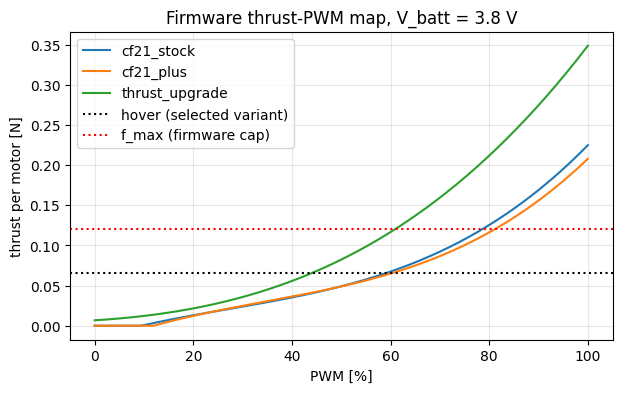

In [ ]:
# Plot of the map for the three variants (nominal V_batt)
pwm_ax = np.linspace(0, 1, 200)
fig, ax = plt.subplots(figsize=(7, 4))
for name, var in VARIANTS.items():
    c0, c1_, c2, c3 = var["vm2t"]
    V = PAR["V_batt"] * pwm_ax
    ax.plot(pwm_ax * 100, np.maximum(c0 + c1_ * V + c2 * V**2 + c3 * V**3, 0), label=name)
ax.axhline(PAR["m"] * PAR["g0"] / 4, color="k", ls=":", label="hover (selected variant)")
ax.axhline(PAR["f_max"], color="r", ls=":", label="f_max (firmware cap)")
ax.set_xlabel("PWM [%]"); ax.set_ylabel("thrust per motor [N]"); ax.grid(alpha=0.3); ax.legend()
ax.set_title(f"Firmware thrust-PWM map, V_batt = {PAR['V_batt']} V")
plt.show()

## 2. SymPy symbols
State, input, wind and physical parameters stay **symbolic**: you can change the numbers without regenerating the equations.

In [ ]:
# State  x = [p (3), q (4), v (3), omega (3)]  -> 13 components
px, py, pz = sp.symbols("px py pz", real=True)
qw, qx, qy, qz = sp.symbols("qw qx qy qz", real=True)
vx, vy, vz = sp.symbols("vx vy vz", real=True)
wx, wy, wz = sp.symbols("wx wy wz", real=True)
# Input  u = [f1, f2, f3, f4]  single rotor thrusts [N]
f1, f2, f3, f4 = sp.symbols("f1 f2 f3 f4", real=True)
# Disturbance: wind velocity in the world frame [m/s] (enters the drag)
vwx, vwy, vwz = sp.symbols("vwx vwy vwz", real=True)
# Physical parameters (kept symbolic: change them without regenerating anything)
m, Jxx, Jyy, Jzz, l, c_tau, dx, dy, dz, g0 = sp.symbols(
    "m Jxx Jyy Jzz l c_tau dx dy dz g0", positive=True)

p = sp.Matrix([px, py, pz])
q = sp.Matrix([qw, qx, qy, qz])
v = sp.Matrix([vx, vy, vz])
w = sp.Matrix([wx, wy, wz])
u = sp.Matrix([f1, f2, f3, f4])
v_w = sp.Matrix([vwx, vwy, vwz])
x = sp.Matrix.vstack(p, q, v, w)

PAR_SYM = [m, Jxx, Jyy, Jzz, l, c_tau, dx, dy, dz, g0]
PAR_NAMES = [str(s) for s in PAR_SYM]
P_NOM = np.array([PAR[n] for n in PAR_NAMES])

In [ ]:
x.T, u.T, v_w.T

([px  py  pz  qw  qx  qy  qz  vx  vy  vz  wx  wy  wz], [f₁  f₂  f₃  f₄], [vwx  ↪

↪  vwy  vwz])

## 3. Quaternion algebra
Hamilton product $\mathbf a\odot\mathbf b$ and rotation matrix $R(\mathbf q)$ (valid for a unit quaternion).

In [ ]:
def quat_mult(a, b):
    """Hamilton product a (x) b, quaternions as [w, x, y, z]."""
    aw, ax, ay, az = a
    bw, bx, by, bz = b
    return sp.Matrix([
        aw * bw - ax * bx - ay * by - az * bz,
        aw * bx + ax * bw + ay * bz - az * by,
        aw * by - ax * bz + ay * bw + az * bx,
        aw * bz + ax * by - ay * bx + az * bw,
    ])


def quat_to_rotmat(qq):
    """R(q) for a UNIT quaternion: v_I = R(q) v_B."""
    w_, x_, y_, z_ = qq
    return sp.Matrix([
        [1 - 2 * (y_**2 + z_**2), 2 * (x_ * y_ - w_ * z_), 2 * (x_ * z_ + w_ * y_)],
        [2 * (x_ * y_ + w_ * z_), 1 - 2 * (x_**2 + z_**2), 2 * (y_ * z_ - w_ * x_)],
        [2 * (x_ * z_ - w_ * y_), 2 * (y_ * z_ + w_ * x_), 1 - 2 * (x_**2 + y_**2)],
    ])


R = quat_to_rotmat(q)

R

⎡      2       2                                              ⎤
⎢- 2⋅qy  - 2⋅qz  + 1  -2⋅qw⋅qz + 2⋅qx⋅qy    2⋅qw⋅qy + 2⋅qx⋅qz ⎥
⎢                                                             ⎥
⎢                           2       2                         ⎥
⎢ 2⋅qw⋅qz + 2⋅qx⋅qy   - 2⋅qx  - 2⋅qz  + 1  -2⋅qw⋅qx + 2⋅qy⋅qz ⎥
⎢                                                             ⎥
⎢                                                2       2    ⎥
⎣-2⋅qw⋅qy + 2⋅qx⋅qz    2⋅qw⋅qx + 2⋅qy⋅qz   - 2⋅qx  - 2⋅qy  + 1⎦

Numerical check: $R(\mathbf q)\mathbf v$ must equal the vector part of $\mathbf q\odot[0,\mathbf v]\odot\mathbf q^*$.

In [ ]:
# Numerical check: R(q) v == vector part of q (x) [0, v] (x) q*
_qn = np.random.default_rng(0).normal(size=4)
_qn /= np.linalg.norm(_qn)
_vt = sp.Matrix([0.3, -1.2, 0.7])
_qs = sp.Matrix(_qn)
_qc = sp.Matrix([_qn[0], -_qn[1], -_qn[2], -_qn[3]])
_rot1 = quat_mult(quat_mult(_qs, sp.Matrix([0, *_vt])), _qc)[1:, 0]
_rot2 = quat_to_rotmat(_qs) * _vt
assert np.allclose(np.array(_rot1, float), np.array(_rot2, float))
print("OK: R(q) consistent with the Hamilton product")

OK: R(q) consistent with the Hamilton product


## 4. Allocation (mixer)
$[T,\ \tau_x,\ \tau_y,\ \tau_z]^\top = M\,[f_1,f_2,f_3,f_4]^\top$

Eq. (2) of the paper uses a different motor numbering. Here the matrix is the firmware one ([power_distribution_quadrotor.c](https://github.com/bitcraze/crazyflie-firmware/blob/master/src/modules/src/power_distribution_quadrotor.c)), so $f_1..f_4$ map to the real motors M1..M4.

In [ ]:
# The paper (eq. 2) uses:
#   tau = [ l/sqrt2 ( f1+f2-f3-f4), l/sqrt2 (-f1+f2+f3-f4), c_tau (f1-f2+f3-f4)]
# i.e. an X configuration with a different motor numbering/spin direction.
# Here I use the matrix consistent with the Crazyflie firmware
# (powerDistribution in power_distribution_quadrotor.c), so f1..f4 map to the
# real motors M1..M4.
a_arm = l / sp.sqrt(2)
M_alloc = sp.Matrix([
    [1, 1, 1, 1],                       # T     = sum of f_i
    [-a_arm, -a_arm, a_arm, a_arm],     # tau_x = roll
    [-a_arm, a_arm, a_arm, -a_arm],     # tau_y = pitch
    [-c_tau, c_tau, -c_tau, c_tau],     # tau_z = yaw (reaction torques)
])
Ttau = M_alloc * u
T = Ttau[0]
tau = Ttau[1:, 0]
f_T = sp.Matrix([0, 0, T])              # collective thrust in the body frame

M_alloc

⎡  1       1       1      1   ⎤
⎢                             ⎥
⎢-√2⋅l   -√2⋅l   √2⋅l    √2⋅l ⎥
⎢──────  ──────  ────    ──── ⎥
⎢  2       2      2       2   ⎥
⎢                             ⎥
⎢-√2⋅l    √2⋅l   √2⋅l   -√2⋅l ⎥
⎢──────   ────   ────   ──────⎥
⎢  2       2      2       2   ⎥
⎢                             ⎥
⎣-cₜₐᵤ    cₜₐᵤ   -cₜₐᵤ   cₜₐᵤ ⎦

## 5. Nonlinear dynamics $\dot{\mathbf x} = f(\mathbf x,\mathbf u,\mathbf v_w)$
Note: the pasted equation was missing a transpose. The drag is diagonal in the **body** frame, hence $-R\,D\,R^\top\mathbf v$ (rotate $\mathbf v$ into the body frame, apply $D$, rotate back to the world frame). Wind enters through the airspeed $\mathbf v - \mathbf v_w$.

In [ ]:
g_vec = sp.Matrix([0, 0, -g0])
J = sp.diag(Jxx, Jyy, Jzz)
D = sp.diag(dx, dy, dz)

# Airspeed: the drag "sees" v - v_w (v_w = 0 -> eq. (3) of the paper).
v_rel = v - v_w

p_dot = v
q_dot = sp.Rational(1, 2) * quat_mult(q, sp.Matrix([0, wx, wy, wz]))
# NB: the pasted text is missing a transpose. The drag is diagonal in the
# body frame:  a_drag = -R D R^T v  (rotate v into B, apply D, rotate back)
v_dot = g_vec + (R * f_T) / m - R * D * R.T * v_rel
w_dot = J.inv() * (tau - w.cross(J * w))

f_expr = sp.Matrix.vstack(p_dot, q_dot, v_dot, w_dot)

In [ ]:
print("\nTranslational dynamics (z component of v_dot):")
display(sp.simplify(v_dot[2].subs({vwx: 0, vwy: 0, vwz: 0, vx: 0, vy: 0, vz: 0})))
print("\nRotational dynamics (omega_dot):")
display(sp.simplify(w_dot))


Translational dynamics (z component of v_dot):



Rotational dynamics (omega_dot):


⎡2⋅Jyy⋅wy⋅wz - 2⋅Jzz⋅wy⋅wz - √2⋅f₁⋅l - √2⋅f₂⋅l + √2⋅f₃⋅l + √2⋅f₄⋅l ⎤
⎢───────────────────────────────────────────────────────────────── ⎥
⎢                              2⋅Jxx                               ⎥
⎢                                                                  ⎥
⎢-2⋅Jxx⋅wx⋅wz + 2⋅Jzz⋅wx⋅wz - √2⋅f₁⋅l + √2⋅f₂⋅l + √2⋅f₃⋅l - √2⋅f₄⋅l⎥
⎢──────────────────────────────────────────────────────────────────⎥
⎢                              2⋅Jyy                               ⎥
⎢                                                                  ⎥
⎢  Jxx⋅wx⋅wy - Jyy⋅wx⋅wy - cₜₐᵤ⋅f₁ + cₜₐᵤ⋅f₂ - cₜₐᵤ⋅f₃ + cₜₐᵤ⋅f₄   ⎥
⎢  ─────────────────────────────────────────────────────────────   ⎥
⎣                               Jzz                                ⎦

Quaternion kinematics $\dot{\mathbf q}$:

In [ ]:
q_dot

⎡  qx⋅wx   qy⋅wy   qz⋅wz⎤
⎢- ───── - ───── - ─────⎥
⎢    2       2       2  ⎥
⎢                       ⎥
⎢ qw⋅wx   qy⋅wz   qz⋅wy ⎥
⎢ ───── + ───── - ───── ⎥
⎢   2       2       2   ⎥
⎢                       ⎥
⎢ qw⋅wy   qx⋅wz   qz⋅wx ⎥
⎢ ───── - ───── + ───── ⎥
⎢   2       2       2   ⎥
⎢                       ⎥
⎢ qw⋅wz   qx⋅wy   qy⋅wx ⎥
⎢ ───── + ───── - ───── ⎥
⎣   2       2       2   ⎦

## 6. Linearization
$$\delta\dot{\mathbf x} = A\,\delta\mathbf x + B\,\delta\mathbf u + E\,\delta\mathbf v_w,\qquad A=\frac{\partial f}{\partial \mathbf x},\ B=\frac{\partial f}{\partial \mathbf u},\ E=\frac{\partial f}{\partial \mathbf v_w}$$
The Jacobians are symbolic and valid at **any** point (useful for an LTV-MPC along a trajectory).

In [ ]:
#  delta_x_dot = A delta_x + B delta_u + E delta_v_w
A_sym = f_expr.jacobian(x)       # 13 x 13
B_sym = f_expr.jacobian(u)       # 13 x 4
E_sym = f_expr.jacobian(v_w)     # 13 x 3 (wind as a disturbance)

print(A_sym.shape, B_sym.shape, E_sym.shape)
A_sym[7:10, 3:7]   # example: dv_dot/dq at a generic point

(13, 13) (13, 4) (13, 3)


⎡                                                                              ↪
⎢-(-vwx + vx)⋅(-4⋅dy⋅qz⋅(-2⋅qw⋅qz + 2⋅qx⋅qy) + 4⋅dz⋅qy⋅(2⋅qw⋅qy + 2⋅qx⋅qz)) -  ↪
⎢                                                                              ↪
⎢                                                                              ↪
⎢              ⎛        ⎛      2       2    ⎞           ⎛      2       2    ⎞  ↪
⎢- (-vwx + vx)⋅⎝2⋅dx⋅qz⋅⎝- 2⋅qy  - 2⋅qz  + 1⎠ - 2⋅dy⋅qz⋅⎝- 2⋅qx  - 2⋅qz  + 1⎠  ↪
⎢                                                                              ↪
⎢                                                                              ↪
⎢                          ⎛          ⎛      2       2    ⎞                    ↪
⎢            - (-vwx + vx)⋅⎝- 2⋅dx⋅qy⋅⎝- 2⋅qy  - 2⋅qz  + 1⎠ + 2⋅dy⋅qx⋅(-2⋅qw⋅q ↪
⎣                                                                              ↪

↪             ⎛        ⎛      2       2    ⎞           ⎛      2       2    ⎞   ↪
↪ (-vwy + vy)⋅⎝2⋅dx⋅qz⋅⎝- 2

### Equilibrium point: hover
Level, zero yaw, still air, $f_i = mg/4$. The $\dot{\mathbf v}$ rows contain $\pm 2g$ (because $q_x\approx\phi/2$, $q_y\approx\theta/2$: tilting accelerates the drone sideways) and $-d_x,-d_y,-d_z$ (drag damping).

In [ ]:
# --- Equilibrium point: hover, level, zero yaw, still air ---------------------
f_h = m * g0 / 4
hover_subs = {px: 0, py: 0, pz: 0, qw: 1, qx: 0, qy: 0, qz: 0,
              vx: 0, vy: 0, vz: 0, wx: 0, wy: 0, wz: 0,
              f1: f_h, f2: f_h, f3: f_h, f4: f_h, vwx: 0, vwy: 0, vwz: 0}

assert sp.simplify(f_expr.subs(hover_subs)) == sp.zeros(13, 1), "not an equilibrium"

A_hover_sym = sp.simplify(A_sym.subs(hover_subs))
B_hover_sym = sp.simplify(B_sym.subs(hover_subs))
print("\nA at hover (symbolic) - rows v_dot, columns [q, v]:")
display(A_hover_sym[7:10, 3:10])
# How to read it: dvx/dqy = 2 g0, dvy/dqx = -2 g0 -> tilting accelerates
# sideways (qx ~ phi/2, qy ~ theta/2), and -dx, -dy, -dz = drag damping.
print("\nB at hover (symbolic) - rows omega_dot:")
display(B_hover_sym[10:13, :])


A at hover (symbolic) - rows v_dot, columns [q, v]:


⎡0    0    2⋅g₀  0  -dx   0    0 ⎤
⎢                                ⎥
⎢0  -2⋅g₀   0    0   0   -dy   0 ⎥
⎢                                ⎥
⎣0    0     0    0   0    0   -dz⎦


B at hover (symbolic) - rows omega_dot:


⎡-√2⋅l   -√2⋅l   √2⋅l    √2⋅l  ⎤
⎢──────  ──────  ─────   ───── ⎥
⎢2⋅Jxx   2⋅Jxx   2⋅Jxx   2⋅Jxx ⎥
⎢                              ⎥
⎢-√2⋅l   √2⋅l    √2⋅l    -√2⋅l ⎥
⎢──────  ─────   ─────   ──────⎥
⎢2⋅Jyy   2⋅Jyy   2⋅Jyy   2⋅Jyy ⎥
⎢                              ⎥
⎢-cₜₐᵤ    cₜₐᵤ   -cₜₐᵤ    cₜₐᵤ ⎥
⎢──────   ────   ──────   ──── ⎥
⎣ Jzz     Jzz     Jzz     Jzz  ⎦

### Numerical evaluation

In [ ]:
# --- Numerical evaluation -----------------------------------------------------
x_h = np.array([0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0], float)
u_h = np.full(4, PAR["m"] * PAR["g0"] / 4)
vw_h = np.zeros(3)

args = (x, u, v_w, PAR_SYM)
f_num = sp.lambdify(args, f_expr, "numpy", cse=True)
A_num = sp.lambdify(args, A_sym, "numpy", cse=True)
B_num = sp.lambdify(args, B_sym, "numpy", cse=True)
E_num = sp.lambdify(args, E_sym, "numpy", cse=True)

A_h = np.array(A_num(x_h, u_h, vw_h, P_NOM), float)
B_h = np.array(B_num(x_h, u_h, vw_h, P_NOM), float)
E_h = np.array(E_num(x_h, u_h, vw_h, P_NOM), float)

print('A at hover (13x13):')
print(A_h)

A at hover (13x13):
[[  0.       0.       0.       0.       0.       0.       0.       1.       0.       0.       0.       0.       0.    ]
 [  0.       0.       0.       0.       0.       0.       0.       0.       1.       0.       0.       0.       0.    ]
 [  0.       0.       0.       0.       0.       0.       0.       0.       0.       1.       0.       0.       0.    ]
 [  0.       0.       0.       0.      -0.      -0.      -0.       0.       0.       0.      -0.      -0.      -0.    ]
 [  0.       0.       0.       0.       0.       0.      -0.       0.       0.       0.       0.5     -0.       0.    ]
 [  0.       0.       0.       0.      -0.       0.       0.       0.       0.       0.       0.       0.5     -0.    ]
 [  0.       0.       0.       0.       0.      -0.       0.       0.       0.       0.      -0.       0.       0.5   ]
 [  0.       0.       0.       0.       0.      19.62     0.      -0.2372  -0.      -0.       0.       0.       0.    ]
 [  0.       0.     

### Eigenvalues and controllability
With 13 states the rank is 12: the $q_w$ direction (quaternion norm) is not controllable. For a linear MPC one uses the reduced 12-state model without $q_w$.

In [ ]:
print("\nEigenvalues of A at hover:", np.round(np.linalg.eigvals(A_h).real, 4))


def ctrb_rank(A, B):
    n = A.shape[0]
    C = np.hstack([np.linalg.matrix_power(A, k) @ B for k in range(n)])
    return np.linalg.matrix_rank(C / np.abs(C).max(axis=0, initial=1e-12))


print(f"Controllability rank (13 states): {ctrb_rank(A_h, B_h)}")
# -> 12: the "qw" direction (quaternion norm) is not controllable, because
#    the quaternion lives on the unit sphere (4 numbers, 3 DOF).
# For a linear MPC the usual choice is the reduced 12-state model without qw
# (at hover the qw row and column are zero):
idx12 = [0, 1, 2, 4, 5, 6, 7, 8, 9, 10, 11, 12]
A12, B12, E12 = A_h[np.ix_(idx12, idx12)], B_h[idx12, :], E_h[idx12, :]
print(f"Controllability rank (12 states, no qw): {ctrb_rank(A12, B12)}")


Eigenvalues of A at hover: [ 0.      0.     -0.2372 -0.2372  0.      0.      0.      0.      0.     -0.2664  0.      0.      0.    ]
Controllability rank (13 states): 12
Controllability rank (12 states, no qw): 12


### ZOH discretization (for the MPC) and saving to `cf21_lineare_hover.npz`

In [ ]:
def c2d_zoh(A, B, dt):
    """Exact zero-order-hold discretization (block matrix exponential)."""
    n, mm = B.shape
    Mx = np.zeros((n + mm, n + mm))
    Mx[:n, :n], Mx[:n, n:] = A, B
    Md = expm(Mx * dt)
    return Md[:n, :n], Md[:n, n:]


DT_MPC = 0.02                                       # 50 Hz, typical for MPC
Ad12, BEd12 = c2d_zoh(A12, np.hstack([B12, E12]), DT_MPC)
Bd12, Ed12 = BEd12[:, :4], BEd12[:, 4:]

np.savez(os.path.join(OUT_DIR, "cf21_lineare_hover.npz"),
         A13=A_h, B13=B_h, E13=E_h, A12=A12, B12=B12, E12=E12,
         Ad12=Ad12, Bd12=Bd12, Ed12=Ed12, dt=DT_MPC, x_hover=x_h, u_hover=u_h,
         idx12=np.array(idx12), par_names=np.array(PAR_NAMES), par=P_NOM)

print(f'Ad12 ({DT_MPC*1000:.0f} ms):')
print(Ad12)

Ad12 (20 ms):
[[ 1.      0.      0.      0.      0.0039  0.      0.02    0.      0.      0.      0.      0.    ]
 [ 0.      1.      0.     -0.0039  0.      0.      0.      0.02    0.     -0.      0.      0.    ]
 [ 0.      0.      1.      0.      0.      0.      0.      0.      0.0199  0.      0.      0.    ]
 [ 0.      0.      0.      1.      0.      0.      0.      0.      0.      0.01    0.      0.    ]
 [ 0.      0.      0.      0.      1.      0.      0.      0.      0.      0.      0.01    0.    ]
 [ 0.      0.      0.      0.      0.      1.      0.      0.      0.      0.      0.      0.01  ]
 [ 0.      0.      0.      0.      0.3915  0.      0.9953  0.      0.      0.      0.002   0.    ]
 [ 0.      0.      0.     -0.3915  0.      0.      0.      0.9953  0.     -0.002   0.      0.    ]
 [ 0.      0.      0.      0.      0.      0.      0.      0.      0.9947  0.      0.      0.    ]
 [ 0.      0.      0.      0.      0.      0.      0.      0.      0.      1.      0.      0.  

## 7. Export: standalone numpy module
Writes `cf21_modello_generato.py` with `f`, `A`, `B`, `E` and `mixer()`, with no SymPy dependency. This is the module to import in the future MPC script.

In [ ]:
def generate_module(path):
    from sympy.printing.numpy import NumPyPrinter
    pr = NumPyPrinter({"fully_qualified_modules": True})   # -> numpy.sqrt(...)

    def body(name, expr, doc):
        reps, (red,) = sp.cse(expr, symbols=sp.numbered_symbols("_t"))
        lines = [f"def {name}(x, u, vw=_VW0, p=P_NOM):",
                 f'    """{doc}"""',
                 "    " + ", ".join(map(str, x)) + " = x",
                 "    " + ", ".join(map(str, u)) + " = u",
                 "    " + ", ".join(map(str, v_w)) + " = vw",
                 "    " + ", ".join(PAR_NAMES) + " = p"]
        lines += [f"    {s} = {pr.doprint(e)}" for s, e in reps]
        r, c = red.shape
        lines.append(f"    out = np.zeros(({r}, {c}))" if c > 1 else f"    out = np.zeros({r})")
        for i in range(r):
            for j in range(c):
                if red[i, j] != 0:
                    idx = f"{i}, {j}" if c > 1 else f"{i}"
                    lines.append(f"    out[{idx}] = {pr.doprint(red[i, j])}")
        lines.append("    return out\n")
        return "\n".join(lines)

    text = [
        '"""Crazyflie 2.1 model, auto-generated by cf21_dinamica_sympy.',
        "State x = [px,py,pz, qw,qx,qy,qz, vx,vy,vz, wx,wy,wz]; input u = [f1..f4] [N];",
        'vw = wind in the world frame [m/s]; p = parameters (see PAR_NAMES). Do not edit by hand."""',
        "import numpy\nimport numpy as np\n",
        f"VARIANT = {VARIANT!r}",
        f"PAR_NAMES = {PAR_NAMES!r}",
        f"P_NOM = np.array({P_NOM.tolist()!r})",
        f"F_MAX = {PAR['f_max']!r}",
        "_VW0 = np.zeros(3)\n",
        "def mixer():",
        '    """Matrix M: [T, tau_x, tau_y, tau_z] = M @ [f1, f2, f3, f4]."""',
        "    m, Jxx, Jyy, Jzz, l, c_tau, dx, dy, dz, g0 = P_NOM",
        "    a = l / np.sqrt(2)",
        "    return np.array([[1, 1, 1, 1], [-a, -a, a, a], [-a, a, a, -a],",
        "                     [-c_tau, c_tau, -c_tau, c_tau]], float)\n",
        body("f", f_expr, "Nonlinear dynamics x_dot (13,)."),
        body("A", A_sym, "Jacobian df/dx (13x13)."),
        body("B", B_sym, "Jacobian df/du (13x4)."),
        body("E", E_sym, "Jacobian df/dvw (13x3)."),
    ]
    with open(path, "w", encoding="utf-8") as fh:
        fh.write("\n".join(text))

In [ ]:
PATH_MOD = os.path.join(OUT_DIR, "cf21_modello_generato.py")
generate_module(PATH_MOD)
spec = importlib.util.spec_from_file_location("cf21_modello_generato", PATH_MOD)
cf = importlib.util.module_from_spec(spec)
spec.loader.exec_module(cf)

# Consistency check between lambdify and the generated module at a random point
_xr = np.r_[np.random.rand(3), _qn, np.random.rand(6)]
_ur, _wr = np.random.rand(4) * 0.1, np.random.rand(3)
assert np.allclose(cf.f(_xr, _ur, _wr), np.ravel(f_num(_xr, _ur, _wr, P_NOM)))
assert np.allclose(cf.A(_xr, _ur, _wr), A_num(_xr, _ur, _wr, P_NOM))
print(f"\nExported module: {PATH_MOD}")


Exported module: /mnt/user-data/outputs/cf21_modello_generato.py


## 7b. Linearization check
Roll torque pulse in open loop: nonlinear model vs linear model at hover. Increase `du` to see where the linearization stops being valid.

In [ ]:
# Small roll torque for 0.1 s, then motors back to hover thrust.
# The drone is unstable/marginally stable in open loop: the comparison only
# makes sense for short times and small perturbations.
def rk4(fun, xk, dt):
    k1 = fun(xk)
    k2 = fun(xk + 0.5 * dt * k1)
    k3 = fun(xk + 0.5 * dt * k2)
    k4 = fun(xk + dt * k3)
    return xk + dt / 6 * (k1 + 2 * k2 + 2 * k3 + k4)


dt_v, N_v = 0.002, 300
du = np.array([-1, -1, 1, 1]) * 0.0005              # [N] -> tau_x > 0
x_nl, dx_lin = x_h.copy(), np.zeros(13)
Ad_v, Bd_v = c2d_zoh(A_h, B_h, dt_v)
val_hist = []
for k in range(N_v):
    uk = u_h + (du if k * dt_v < 0.10 else 0.0)
    x_nl = rk4(lambda s: cf.f(s, uk), x_nl, dt_v)
    x_nl[3:7] /= np.linalg.norm(x_nl[3:7])
    dx_lin = Ad_v @ dx_lin + Bd_v @ (uk - u_h)
    val_hist.append(np.r_[x_nl - x_h, dx_lin])
val_hist = np.array(val_hist)

## 8. Simulation: "joystick" maneuver
In open loop the drone does not stay airborne, so a controller is needed. The joystick commands **world-frame velocities**, which are filtered and integrated into a reference position; a geometric controller (Lee et al. 2010) tracks it. The drag is **not** known to the controller: it acts as a disturbance.

Edit the `MANEUVER` list to change the maneuver.

In [ ]:
# In open loop the drone does not stay airborne: a controller is needed. Here
# the joystick commands VELOCITIES in the world frame (like the CF "velocity
# mode"). The commanded velocity is integrated into a reference position, and
# a geometric controller (Lee et al. 2010, similar to the firmware Mellinger)
# tracks p_ref, v_ref, yaw_ref. The drag is NOT known to the controller: it is
# the disturbance you want to study.
#
#   (duration [s], vx, vy, vz [m/s], yaw_rate [rad/s], motors armed, label)
MANEUVER = [
    (1.0,  0.0,  0.0,  0.0,  0.0, False, "on ground"),
    (2.0,  0.0,  0.0,  0.5,  0.0, True,  "takeoff"),
    (1.5,  0.0,  0.0,  0.0,  0.0, True,  "hover"),
    (2.0,  0.5,  0.0,  0.0,  0.0, True,  "forward (stick up)"),
    (1.0,  0.0,  0.0,  0.0,  0.0, True,  "hover"),
    (2.0,  0.0, -0.5,  0.0,  0.0, True,  "right"),
    (1.0,  0.0,  0.0,  0.0,  0.0, True,  "hover"),
    (2.0,  0.0,  0.0,  0.0,  0.8, True,  "yaw left"),
    (2.0, -0.5,  0.0,  0.0,  0.0, True,  "backward"),
    (2.0,  0.0,  0.5,  0.0,  0.0, True,  "left"),
    (1.0,  0.0,  0.0,  0.0,  0.0, True,  "hover"),
    (3.0,  0.0,  0.0, -0.4,  0.0, True,  "landing"),
    (1.0,  0.0,  0.0,  0.0,  0.0, False, "motors off"),
]

Wind: constant for now. This is where the Dryden model will go: `wind(t, pos)` just has to return the wind velocity [m/s].

In [ ]:
# Wind: constant for now. A Dryden model can be plugged in here: the function
# just has to return the wind velocity [m/s] at time t.
CONST_WIND = np.array([0.0, 0.0, 0.0])


def wind(t, pos):
    return CONST_WIND

Integration step, inverse mixer and controller gains.

In [ ]:
DT = 0.002                       # 500 Hz, like the CF control loop
TAU_STICK = 0.25                 # [s] first-order filter on the stick
Mmix = cf.mixer()
Mmix_inv = np.linalg.inv(Mmix)
Jn = np.diag([PAR["Jxx"], PAR["Jyy"], PAR["Jzz"]])
mn, gn = PAR["m"], PAR["g0"]

# Gains (position: ~2.5 rad/s, attitude: ~25 rad/s bandwidth)
KP = np.diag([6.0, 6.0, 8.0])            # [1/s^2]
KV = np.diag([4.5, 4.5, 5.0])            # [1/s]
W_ATT = np.array([25.0, 25.0, 12.0])     # [rad/s] desired attitude natural frequency
KR = Jn @ np.diag(W_ATT**2)
KW = Jn @ np.diag(2 * 0.9 * W_ATT)
TILT_MAX = np.deg2rad(25)

Geometric controller on $SO(3)$: desired acceleration $\to$ collective thrust and desired attitude $\to$ torques, with attitude error $\mathbf e_R = \tfrac12\left(R_d^\top R - R^\top R_d\right)^\vee$.

In [ ]:
def q2R(qq):
    w_, x_, y_, z_ = qq
    return np.array([
        [1 - 2 * (y_**2 + z_**2), 2 * (x_ * y_ - w_ * z_), 2 * (x_ * z_ + w_ * y_)],
        [2 * (x_ * y_ + w_ * z_), 1 - 2 * (x_**2 + z_**2), 2 * (y_ * z_ - w_ * x_)],
        [2 * (x_ * z_ - w_ * y_), 2 * (y_ * z_ + w_ * x_), 1 - 2 * (x_**2 + y_**2)]])


def vee(S):
    return np.array([S[2, 1], S[0, 2], S[1, 0]])


def controller(xk, p_ref, v_ref, a_ff, yaw_ref):
    """Geometric controller on SO(3) -> [T, tau]."""
    pk, qk, vk, wk = xk[0:3], xk[3:7], xk[7:10], xk[10:13]
    Rk = q2R(qk)
    a_des = -KP @ (pk - p_ref) - KV @ (vk - v_ref) + a_ff
    # tilt limit: |horizontal acceleration| <= g tan(tilt_max)
    a_h = a_des[:2]
    a_lim = gn * np.tan(TILT_MAX)
    if np.linalg.norm(a_h) > a_lim:
        a_des[:2] = a_h / np.linalg.norm(a_h) * a_lim
    F_des = mn * (a_des + np.array([0, 0, gn]))
    zb_d = F_des / np.linalg.norm(F_des)
    xc = np.array([np.cos(yaw_ref), np.sin(yaw_ref), 0.0])
    yb_d = np.cross(zb_d, xc)
    yb_d /= np.linalg.norm(yb_d)
    xb_d = np.cross(yb_d, zb_d)
    R_d = np.column_stack([xb_d, yb_d, zb_d])
    T_cmd = F_des @ Rk[:, 2]                         # projection on current z_B
    e_R = 0.5 * vee(R_d.T @ Rk - Rk.T @ R_d)
    tau_cmd = -KR @ e_R - KW @ wk + np.cross(wk, Jn @ wk)
    return T_cmd, tau_cmd

In [ ]:
# --- Segment setup ------------------------------------------------------------
t_end = sum(s[0] for s in MANEUVER)
N = int(round(t_end / DT))
bounds = np.cumsum([0.0] + [s[0] for s in MANEUVER])


def segment(t):
    i = min(np.searchsorted(bounds, t, side="right") - 1, len(MANEUVER) - 1)
    return MANEUVER[i]

Simulation loop: RK4 at 500 Hz, quaternion renormalized at every step, very simple ground contact.

In [ ]:
# --- Simulation loop ----------------------------------------------------------
xk = x_h.copy()                       # starts on the ground, level
p_ref, v_f, yaw_ref, r_f = xk[0:3].copy(), np.zeros(3), 0.0, 0.0
LOG = {k: [] for k in ["t", "x", "u", "p_ref", "yaw_ref", "vw"]}

for k in range(N):
    t = k * DT
    _, svx, svy, svz, syr, armed, _ = segment(t)
    v_stick = np.array([svx, svy, svz])

    # stick filter + acceleration feed-forward
    a_ff = (v_stick - v_f) / TAU_STICK
    v_f = v_f + DT * a_ff
    r_f = r_f + DT * (syr - r_f) / TAU_STICK
    p_ref = p_ref + DT * v_f
    yaw_ref = yaw_ref + DT * r_f
    if p_ref[2] < 0.0:                # the reference never goes underground
        p_ref[2], v_f[2], a_ff[2] = 0.0, 0.0, 0.0

    if armed:
        T_cmd, tau_cmd = controller(xk, p_ref, v_f, a_ff, yaw_ref)
        uk = np.clip(Mmix_inv @ np.r_[T_cmd, tau_cmd], 0.0, PAR["f_max"])
    else:
        uk = np.zeros(4)

    vw_k = wind(t, xk[0:3])
    xk = rk4(lambda s: cf.f(s, uk, vw_k), xk, DT)
    xk[3:7] /= np.linalg.norm(xk[3:7])              # renormalize the quaternion

    # very simple ground contact (constraint z >= 0)
    if xk[2] <= 0.0:
        xk[2] = 0.0
        if xk[9] < 0.0 or not armed:
            xk[7:10] = 0.0
            xk[10:13] = 0.0

    LOG["t"].append(t + DT)
    LOG["x"].append(xk.copy())
    LOG["u"].append(uk)
    LOG["p_ref"].append(p_ref.copy())
    LOG["yaw_ref"].append(yaw_ref)
    LOG["vw"].append(vw_k)

LOG = {k: np.array(v_) for k, v_ in LOG.items()}
X, U = LOG["x"], LOG["u"]
err = np.linalg.norm(X[:, 0:3] - LOG["p_ref"], axis=1)
print(f"\nSimulation: {t_end:.1f} s, max position error {err.max() * 100:.1f} cm,"
      f" RMS {np.sqrt(np.mean(err**2)) * 100:.1f} cm")
print(f"Max thrust per rotor used: {U.max():.3f} N out of {PAR['f_max']} N")
print(f"Hover PWM (V_batt={PAR['V_batt']} V): {thrust_to_pwm(u_h[0]) * 100:.1f} %")


Simulation: 21.5 s, max position error 1.8 cm, RMS 1.0 cm
Max thrust per rotor used: 0.095 N out of 0.12 N
Hover PWM (V_batt=3.8 V): 59.4 %


## 9. Plots

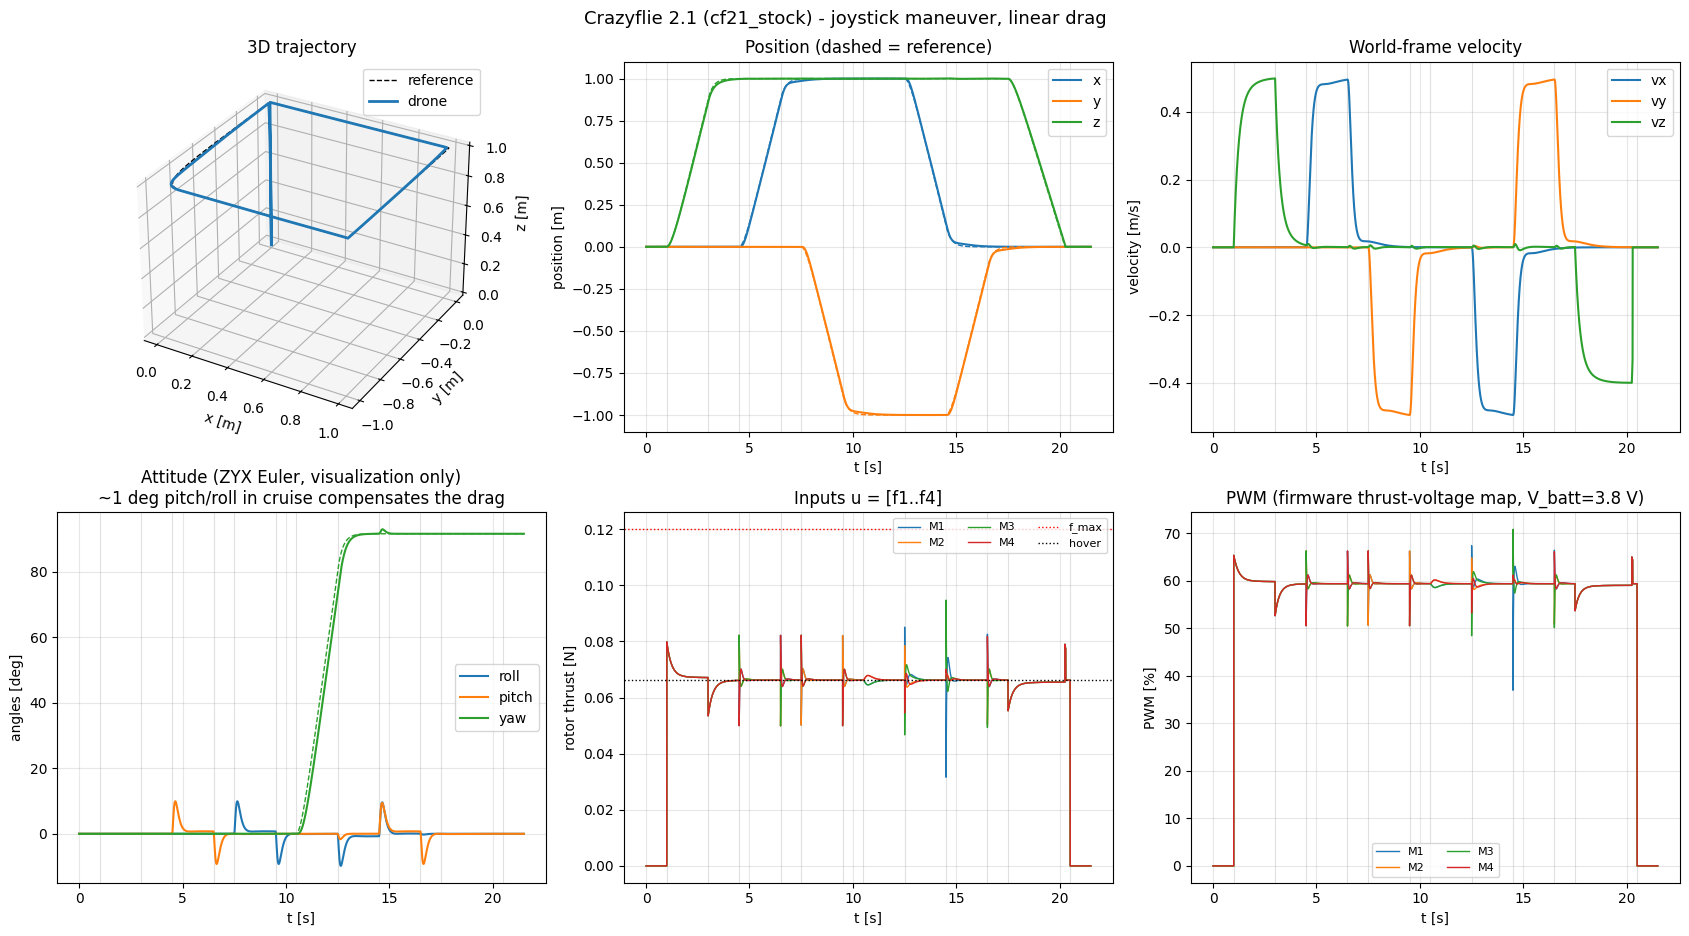

In [ ]:
def quat_to_euler(Q):
    """ZYX (yaw-pitch-roll) in degrees, for visualization only."""
    w_, x_, y_, z_ = Q.T
    roll = np.arctan2(2 * (w_ * x_ + y_ * z_), 1 - 2 * (x_**2 + y_**2))
    pitch = np.arcsin(np.clip(2 * (w_ * y_ - z_ * x_), -1, 1))
    yaw = np.arctan2(2 * (w_ * z_ + x_ * y_), 1 - 2 * (y_**2 + z_**2))
    return np.rad2deg(np.c_[roll, pitch, np.unwrap(yaw)])


tt = LOG["t"]
eul = quat_to_euler(X[:, 3:7])
pwm = thrust_to_pwm(U) * 100

fig = plt.figure(figsize=(17, 9.5))
fig.suptitle(f"Crazyflie 2.1 ({VARIANT}) - joystick maneuver, linear drag", fontsize=13)


def mark_segments(ax):
    for b in bounds[1:-1]:
        ax.axvline(b, color="0.88", lw=0.8, zorder=0)
    ax.grid(alpha=0.3)
    ax.set_xlabel("t [s]")


ax3 = fig.add_subplot(2, 3, 1, projection="3d")
ax3.plot(*LOG["p_ref"].T, "k--", lw=1, label="reference")
ax3.plot(*X[:, 0:3].T, "C0", lw=2, label="drone")
ax3.set_xlabel("x [m]"); ax3.set_ylabel("y [m]"); ax3.set_zlabel("z [m]")
ax3.legend(); ax3.set_title("3D trajectory")

ax = fig.add_subplot(2, 3, 2)
for i, c in enumerate("xyz"):
    ax.plot(tt, X[:, i], f"C{i}", label=c)
    ax.plot(tt, LOG["p_ref"][:, i], f"C{i}--", lw=1)
mark_segments(ax); ax.legend()
ax.set_ylabel("position [m]"); ax.set_title("Position (dashed = reference)")

ax = fig.add_subplot(2, 3, 3)
for i, c in enumerate(["vx", "vy", "vz"]):
    ax.plot(tt, X[:, 7 + i], f"C{i}", label=c)
mark_segments(ax); ax.legend()
ax.set_ylabel("velocity [m/s]"); ax.set_title("World-frame velocity")

ax = fig.add_subplot(2, 3, 4)
for i, c in enumerate(["roll", "pitch", "yaw"]):
    ax.plot(tt, eul[:, i], f"C{i}", label=c)
ax.plot(tt, np.rad2deg(LOG["yaw_ref"]), "C2--", lw=1)
mark_segments(ax); ax.legend()
ax.set_ylabel("angles [deg]")
ax.set_title("Attitude (ZYX Euler, visualization only)\n"
             "~1 deg pitch/roll in cruise compensates the drag")

ax = fig.add_subplot(2, 3, 5)
for i in range(4):
    ax.plot(tt, U[:, i], f"C{i}", lw=1, label=f"M{i + 1}")
ax.axhline(PAR["f_max"], color="r", ls=":", lw=1, label="f_max")
ax.axhline(PAR["m"] * PAR["g0"] / 4, color="k", ls=":", lw=1, label="hover")
mark_segments(ax); ax.legend(ncol=3, fontsize=8)
ax.set_ylabel("rotor thrust [N]"); ax.set_title("Inputs u = [f1..f4]")

ax = fig.add_subplot(2, 3, 6)
for i in range(4):
    ax.plot(tt, pwm[:, i], f"C{i}", lw=1, label=f"M{i + 1}")
mark_segments(ax); ax.legend(ncol=2, fontsize=8)
ax.set_ylabel("PWM [%]")
ax.set_title(f"PWM (firmware thrust-voltage map, V_batt={PAR['V_batt']} V)")
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "cf21_manovra.png"), dpi=130)
plt.show()

# Linearization check

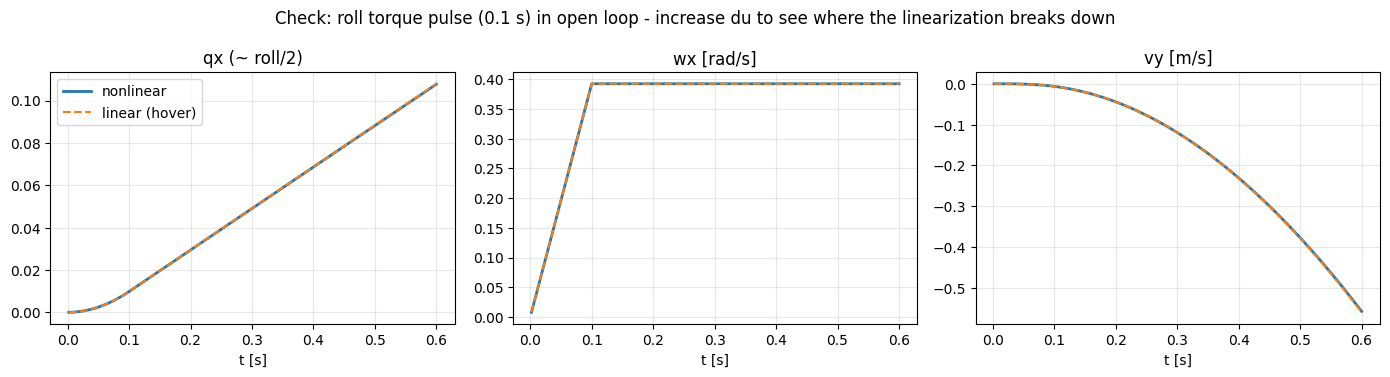

In [ ]:
fig2, axs = plt.subplots(1, 3, figsize=(14, 3.8))
tv = np.arange(1, N_v + 1) * dt_v
for ax, (i, name) in zip(axs, [(4, "qx (~ roll/2)"), (10, "wx [rad/s]"), (8, "vy [m/s]")]):
    ax.plot(tv, val_hist[:, i], "C0", lw=2, label="nonlinear")
    ax.plot(tv, val_hist[:, 13 + i], "C1--", label="linear (hover)")
    ax.set_title(name); ax.set_xlabel("t [s]"); ax.grid(alpha=0.3)
axs[0].legend()
fig2.suptitle("Check: roll torque pulse (0.1 s) in open loop - "
              "increase du to see where the linearization breaks down")
fig2.tight_layout()
fig2.savefig(os.path.join(OUT_DIR, "cf21_validazione_linearizzazione.png"), dpi=130)

plt.show()